# Density on particles

In [1]:
import gsw
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf

### We load our ```particle```

In [2]:
store = "/work/bk1450/b383184/Amazon/Mercator/data/tracks_45678/Parcels_run_45678_1993-01-06 00:00:00.zarr"

In [3]:
## example
# 1. Provide your data (Example values)
practical_salinity = 35.0  # psu
temperature_insitu = 15.0  # °C
pressure = 100.0         # dbar
longitude = -125.0       # deg E
latitude = 45.0          # deg N

# 2. Convert Practical Salinity to Absolute Salinity
SA = gsw.SA_from_SP(practical_salinity, pressure, longitude, latitude)

# 3. Convert in-situ Temperature to Conservative Temperature
CT = gsw.CT_from_t(SA, temperature_insitu, pressure)

# 4. Compute In-Situ Density (kg/m^3)
density = gsw.rho(SA, CT, pressure)
print(f"TEOS-10 Density: {density:.2f} kg/m^3")


TEOS-10 Density: 1026.42 kg/m^3


## In situ density

In [5]:
ds = xr.open_zarr(store)
# trim trailing obs steps where no particle has data
num_valid = int(ds.lat.notnull().any("trajectory").sum().compute().data[()])
ds = ds.isel(obs=slice(0, num_valid)).compute()
ds

<xarray.Dataset> Size: 296MB
Dimensions:     (trajectory: 10000, obs: 741)
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * trajectory  (trajectory) int64 80kB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float64 59MB 0.2145 0.2162 ... 20.24 nan
    lon         (trajectory, obs) float64 59MB -49.28 -49.27 ... -67.37 nan
    sal         (trajectory, obs) float32 30MB 21.31 21.11 20.9 ... 36.02 nan
    temp        (trajectory, obs) float32 30MB 28.58 28.61 28.63 ... 27.77 nan
    time        (trajectory, obs) datetime64[ns] 59MB 1993-01-06 ... NaT
    z           (trajectory, obs) float64 59MB 4.637 4.606 4.571 ... 0.08311 nan
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleSampleTSAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [20]:
p   = gsw.p_from_z(-ds.z, ds.lat)                 # real pressure at particle depth
SA  = gsw.SA_from_SP(ds.sal, p, ds.lon, ds.lat)  # practical -> absolute salinity
CT  = gsw.CT_from_pt(SA, ds.temp)                # potential -> conservative temp
rho = gsw.rho(SA, CT, p)                         # IN-SITU density (real p)

## Buoyancy

In [29]:
## buoyancy
g = 9.81 #m/s2
rho_0 = 1025
b = -g * (rho - rho_0) / rho_0
b = b.rename('buoyancy')
b

<xarray.DataArray 'buoyancy' (trajectory: 10000, obs: 741)> Size: 59MB
array([[0.12465331, 0.12618926, 0.12772512, ..., 0.08196526, 0.08224188,
               nan],
       [0.13553622, 0.13296265, 0.14261505, ..., 0.24024502, 0.24024502,
               nan],
       [0.18470001, 0.18536774, 0.18621133, ..., 0.00970192, 0.00965298,
               nan],
       ...,
       [0.21273239, 0.11603298, 0.11853877, ..., 0.24024502, 0.24024502,
               nan],
       [0.15456965, 0.15667719, 0.16126727, ..., 0.0146963 , 0.01478303,
               nan],
       [0.13651909, 0.13886191, 0.14109559, ..., 0.01745139, 0.01687931,
               nan]], shape=(10000, 741))
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * trajectory  (trajectory) int64 80kB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999

In [28]:
# potential density referenced to the surface (0 dbar)
rho_pot = gsw.rho(SA, CT, 0)

# convenience version: sigma0 = rho_pot - 1000
sigma0 = gsw.sigma0(SA, CT)          # e.g. 25.3 instead of 1025.3
sigma0 = sigma0.rename('sigma0')
sigma0

<xarray.DataArray 'sigma0' (trajectory: 10000, obs: 741)> Size: 59MB
array([[11.95560355, 11.79524972, 11.63492304, ..., 16.43584187,
        16.40693901,         nan],
       [10.81253594, 11.08062166, 10.07261439, ..., -0.15553584,
        -0.15553584,         nan],
       [ 5.68403455,  5.6146603 ,  5.52698812, ..., 23.74969634,
        23.75581627,         nan],
       ...,
       [ 2.7387373 , 12.84668907, 12.58510728, ..., -0.15553584,
        -0.15553584,         nan],
       [ 8.84189715,  8.62213075,  8.14296272, ..., 23.46444173,
        23.45538125,         nan],
       [10.70655455, 10.46296663, 10.23045036, ..., 23.17622823,
        23.23600988,         nan]], shape=(10000, 741))
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * trajectory  (trajectory) int64 80kB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Attributes:
    long_name:      
    standard_name:  sal
    units:          unknown

### σ₀ subduction diagnostic for the selected cluster

The same isopycnal-vs-diapycnal test as further down, but on `clust` (the sampled
pathway group) instead of a single store. **Δσ₀ ≈ 0** → the particle slides along
isopycnals (adiabatic subduction); **Δσ₀ > 0** → it densifies on the way down
(diapycnal transformation).

## Diagnostics — isopycnal (adiabatic) vs. diapycnal subduction

How does NBC/Amazon water reach ~500 m? Two mechanisms, distinguished by whether **potential density is conserved** as a particle sinks:

- **Δσ₀ ≈ 0** → the particle slides *along* tilting isopycnals — **adiabatic subduction** (retroflection / NBC-ring subduction, wind-driven downwelling). Water keeps its identity.
- **Δσ₀ > 0** → the particle gets denser on the way down — **diapycnal transformation** (surface buoyancy loss, then sinking; or interior mixing).

In-situ density can't tell these apart (it always rises with depth from compression), so we track **σ₀** along each trajectory.

In [33]:
# Potential density referenced to 250 dbar (mid-depth of the 0-500 m range).
# Same idea as sigma0, but the reference pressure sits closer to where the deep
# particles actually are, so it carries less thermobaric error over 0-500 m.
# sigma_250 = (gsw.rho(SA, CT, 250) - 1000).rename('sigma_250')

# # sanity check: over this depth range sigma0 and sigma_250 are nearly identical
# print('max |sigma0 - sigma_250| =',
#       float(np.abs(sigma0 - sigma_250).max()), 'kg/m^3')

3 / 10000 particles reach > 200 m


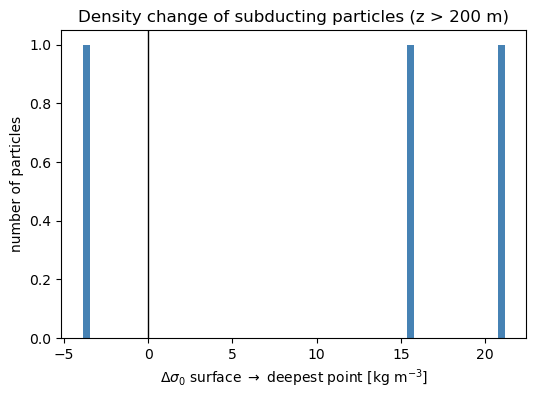

In [34]:
# --- Does potential density change as particles reach their deepest point? ---
# adiabatic (isopycnal) subduction -> dsigma ~ 0
# diapycnal transformation         -> dsigma  > 0  (water becomes denser)
zmax     = ds.z.max('obs')                        # deepest depth each particle reaches
deep_idx = ds.z.fillna(-np.inf).argmax('obs')     # obs index of that deepest point

sigma_start = sigma0.isel(obs=0)                   # start of track, near surface
sigma_deep  = sigma0.isel(obs=deep_idx)            # at the deepest point
dsigma      = sigma_deep - sigma_start

# focus on particles that actually subduct
z_thresh = 200.0                                   # m ; try 300 or 500 too
subd     = zmax > z_thresh
print(f'{int(subd.sum())} / {ds.sizes["trajectory"]} particles reach > {z_thresh:.0f} m')

vals = dsigma.where(subd).values.ravel()
vals = vals[np.isfinite(vals)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(vals, bins=60, color='steelblue')
ax.axvline(0, color='k', lw=1)
ax.set_xlabel(r'$\Delta\sigma_0$ surface $\rightarrow$ deepest point [kg m$^{-3}$]')
ax.set_ylabel('number of particles')
ax.set_title(f'Density change of subducting particles (z > {z_thresh:.0f} m)')
plt.show()

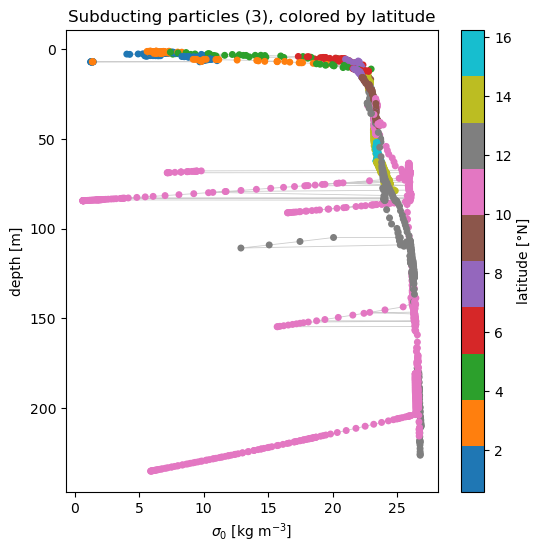

In [40]:
# --- Where (which latitude) do the subducting particles sink? ---
# Path in (sigma0, depth) space, points colored by latitude.
#   vertical alignment        -> sigma0 constant -> adiabatic / isopycnal subduction
#   drift toward denser water -> sigma0 grows    -> diapycnal densification
# Only a few particles subduct here, so plot them all (no subsampling).
idx = np.where(subd.values)[0]

# flatten all points of the subducting particles, colored by latitude
sig = sigma0.isel(trajectory=idx).values.ravel()
zz  = ds.z.isel(trajectory=idx).values.ravel()
lat = ds.lat.isel(trajectory=idx).values.ravel()
m   = np.isfinite(sig) & np.isfinite(zz) & np.isfinite(lat)

fig, ax = plt.subplots(figsize=(6, 6))
# thin grey line per particle to keep the time-order of the path visible
for i in idx:
    ax.plot(sigma0.isel(trajectory=i), ds.z.isel(trajectory=i),
            color='0.8', lw=0.6, zorder=1)
sc = ax.scatter(sig[m], zz[m], c=lat[m], cmap='tab10', s=16, zorder=2,)
ax.invert_yaxis()                       # depth increases downward
cb = fig.colorbar(sc, ax=ax)
cb.set_label('latitude [°N]')
ax.set_xlabel(r'$\sigma_0$ [kg m$^{-3}$]')
ax.set_ylabel('depth [m]')
ax.set_title(f'Subducting particles ({idx.size}), colored by latitude')
plt.show()